# Hybrid Axis Detection: YOLO + OpenCV

Deze notebook combineert twee methodes:

## 1. YOLO object detection
YOLO wordt gebruikt om assen te leren herkennen op basis van gelabelde voorbeelden.

Aanbevolen YOLO classes:

```text
0: left_axis
1: bottom_x_axis
```

- `left_axis` = verticale as links bij horizontal bar charts
- `bottom_x_axis` = horizontale x-as onderaan bij vertical bar charts

## 2. OpenCV line support scanning
OpenCV wordt gebruikt als baseline en post-processing.

De OpenCV-methode doet dit:

```text
verticale lijn gevonden?
↓
scan direct rechts van die lijn
↓
staan daar meerdere horizontale bar-segmenten?
↓
ja = waarschijnlijk left_axis
```

en:

```text
horizontale lijn gevonden?
↓
scan direct boven die lijn
↓
staan daar meerdere verticale bar-segmenten?
↓
ja = waarschijnlijk bottom_x_axis
```

## Waarom hybrid?

YOLO is beter in het herkennen van context.  
OpenCV is handig om de exacte lijn te controleren of te verfijnen.

Dus:

```text
YOLO = waar ongeveer?
OpenCV = klopt de lijn logisch met bars?
```


In [1]:
# Install packages if needed
%pip install opencv-python matplotlib numpy pandas ultralytics

^C
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
except Exception as e:
    YOLO_AVAILABLE = False
    print("YOLO is not available yet:", e)

print("OpenCV version:", cv2.__version__)
print("YOLO available:", YOLO_AVAILABLE)

OpenCV version: 4.13.0
YOLO available: True


ERROR: Could not install packages due to an OSError: [WinError 5] Toegang geweigerd: 'c:\\Users\\Melda\\OneDrive - Office 365 Fontys\\AI, Machine Learning & Data\\Jugo\\ibcs-ml-base\\.venv\\Lib\\site-packages\\torchvision\\_C.pyd'
Check the permissions.



  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached torch-2.11.0-cp314-cp314-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached charset_normalizer-3.4.7-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   -------------

## 1. Project settings

Pas deze paden aan naar jouw project.

Als je nog geen YOLO-model hebt getraind, laat `YOLO_MODEL_PATH` dan staan. De OpenCV baseline werkt dan nog steeds.


In [4]:
IMAGE_PATH = Path("../Dataset/Compliant/7.png")

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# After training YOLO, this should point to your trained model:
YOLO_MODEL_PATH = Path("../runs/detect/train/weights/best.pt")

# YOLO classes:
# 0 = left_axis
# 1 = bottom_x_axis
CLASS_NAMES = {
    0: "left_axis",
    1: "bottom_x_axis"
}

# OpenCV settings from the good version
DARK_THRESHOLD = 235
SATURATION_MAX = 190
BORDER_MARGIN_RATIO = 0.025

MIN_VERTICAL_LINE_HEIGHT = 25
MAX_VERTICAL_LINE_WIDTH = 10
MIN_HORIZONTAL_LINE_WIDTH = 25
MAX_HORIZONTAL_LINE_HEIGHT = 10
MAX_LINE_SPAN_RATIO = 0.80

RIGHT_SCAN_GAP = 8
RIGHT_SCAN_WIDTH = 180
MIN_RIGHT_RUN_PIXELS = 18
MIN_BAR_BAND_HEIGHT = 3

UP_SCAN_GAP = 8
UP_SCAN_HEIGHT = 160
MIN_UP_RUN_PIXELS = 18
MIN_BAR_BAND_WIDTH = 3

MIN_SUPPORTING_BARS = 2

MAX_AXES_TO_DRAW = 30

## 2. General display helpers

In [5]:

def show_image(title, image, figsize=(12, 8), cmap=None):
    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def load_image(path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


# Part A - OpenCV line support scanning

Deze code is gebaseerd op de versie die bij jou al veel beter werkte.


In [6]:

def create_dark_mask(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]

    mask = np.zeros_like(gray, dtype=np.uint8)
    mask[(gray < DARK_THRESHOLD) & (saturation < SATURATION_MAX)] = 255

    return mask


def remove_outer_border(mask):
    h, w = mask.shape[:2]
    mx = int(w * BORDER_MARGIN_RATIO)
    my = int(h * BORDER_MARGIN_RATIO)

    cleaned = mask.copy()
    cleaned[:my, :] = 0
    cleaned[h-my:, :] = 0
    cleaned[:, :mx] = 0
    cleaned[:, w-mx:] = 0

    return cleaned


def make_horizontal_structure_mask(mask):
    h, w = mask.shape[:2]
    kernel_width = max(15, int(w * 0.025))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 3))
    horizontal_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return horizontal_mask


def make_vertical_structure_mask(mask):
    h, w = mask.shape[:2]
    kernel_height = max(15, int(h * 0.025))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, kernel_height))
    vertical_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    return vertical_mask


def detect_vertical_line_candidates(mask, image_shape):
    h, w = image_shape[:2]
    kernel_height = max(20, int(h * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, kernel_height))

    vertical_lines_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(vertical_lines_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        if bh < MIN_VERTICAL_LINE_HEIGHT:
            continue
        if bw > MAX_VERTICAL_LINE_WIDTH:
            continue
        if bh > h * MAX_LINE_SPAN_RATIO:
            continue

        lines.append({
            "source": "opencv",
            "axis_type": "left_axis",
            "x1": int(x + bw / 2),
            "y1": int(y),
            "x2": int(x + bw / 2),
            "y2": int(y + bh),
            "width": int(bw),
            "height": int(bh)
        })

    return lines, vertical_lines_mask


def detect_horizontal_line_candidates(mask, image_shape):
    h, w = image_shape[:2]
    kernel_width = max(20, int(w * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 1))

    horizontal_lines_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(horizontal_lines_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        if bw < MIN_HORIZONTAL_LINE_WIDTH:
            continue
        if bh > MAX_HORIZONTAL_LINE_HEIGHT:
            continue
        if bw > w * MAX_LINE_SPAN_RATIO:
            continue

        lines.append({
            "source": "opencv",
            "axis_type": "bottom_x_axis",
            "x1": int(x),
            "y1": int(y + bh / 2),
            "x2": int(x + bw),
            "y2": int(y + bh / 2),
            "width": int(bw),
            "height": int(bh)
        })

    return lines, horizontal_lines_mask


def count_horizontal_bar_support(line, horizontal_mask):
    h, w = horizontal_mask.shape[:2]
    x = line["x1"]
    y1 = max(0, line["y1"])
    y2 = min(h - 1, line["y2"])

    scan_x1 = min(w - 1, x + 1)
    scan_x2 = min(w, x + RIGHT_SCAN_GAP + RIGHT_SCAN_WIDTH)

    if scan_x2 <= scan_x1 or y2 <= y1:
        return 0, []

    region = horizontal_mask[y1:y2 + 1, scan_x1:scan_x2]
    row_counts = np.count_nonzero(region, axis=1)
    supported_rows = row_counts >= MIN_RIGHT_RUN_PIXELS

    bands = []
    start = None

    for idx, value in enumerate(supported_rows):
        if value and start is None:
            start = idx
        elif not value and start is not None:
            end = idx - 1
            if end - start + 1 >= MIN_BAR_BAND_HEIGHT:
                bands.append((y1 + start, y1 + end))
            start = None

    if start is not None:
        end = len(supported_rows) - 1
        if end - start + 1 >= MIN_BAR_BAND_HEIGHT:
            bands.append((y1 + start, y1 + end))

    merged = []
    for band in bands:
        if not merged:
            merged.append(list(band))
        else:
            if band[0] - merged[-1][1] <= 4:
                merged[-1][1] = band[1]
            else:
                merged.append(list(band))

    merged = [(int(a), int(b)) for a, b in merged]
    return len(merged), merged


def count_vertical_bar_support(line, vertical_mask):
    h, w = vertical_mask.shape[:2]
    y = line["y1"]
    x1 = max(0, line["x1"])
    x2 = min(w - 1, line["x2"])

    scan_y1 = max(0, y - UP_SCAN_GAP - UP_SCAN_HEIGHT)
    scan_y2 = max(0, y - 1)

    if scan_y2 <= scan_y1 or x2 <= x1:
        return 0, []

    region = vertical_mask[scan_y1:scan_y2 + 1, x1:x2 + 1]
    col_counts = np.count_nonzero(region, axis=0)
    supported_cols = col_counts >= MIN_UP_RUN_PIXELS

    bands = []
    start = None

    for idx, value in enumerate(supported_cols):
        if value and start is None:
            start = idx
        elif not value and start is not None:
            end = idx - 1
            if end - start + 1 >= MIN_BAR_BAND_WIDTH:
                bands.append((x1 + start, x1 + end))
            start = None

    if start is not None:
        end = len(supported_cols) - 1
        if end - start + 1 >= MIN_BAR_BAND_WIDTH:
            bands.append((x1 + start, x1 + end))

    merged = []
    for band in bands:
        if not merged:
            merged.append(list(band))
        else:
            if band[0] - merged[-1][1] <= 4:
                merged[-1][1] = band[1]
            else:
                merged.append(list(band))

    merged = [(int(a), int(b)) for a, b in merged]
    return len(merged), merged


def find_left_axes_by_support_scanning(vertical_lines, horizontal_mask):
    axes = []

    for line in vertical_lines:
        support_count, bands = count_horizontal_bar_support(line, horizontal_mask)

        if support_count < MIN_SUPPORTING_BARS:
            continue

        y1 = min(b[0] for b in bands)
        y2 = max(b[1] for b in bands)
        x = line["x1"]

        pad = int((y2 - y1) * 0.12)
        y1 = max(0, y1 - pad)
        y2 = min(horizontal_mask.shape[0] - 1, y2 + pad)

        score = support_count * 120 + (y2 - y1) + line["height"] * 0.25

        axes.append({
            "source": "opencv",
            "axis_type": "left_axis",
            "x1": int(x),
            "y1": int(y1),
            "x2": int(x),
            "y2": int(y2),
            "supporting_bars": int(support_count),
            "confidence": None,
            "score": float(score)
        })

    return axes


def find_bottom_axes_by_support_scanning(horizontal_lines, vertical_mask):
    axes = []

    for line in horizontal_lines:
        support_count, bands = count_vertical_bar_support(line, vertical_mask)

        if support_count < MIN_SUPPORTING_BARS:
            continue

        x1 = min(b[0] for b in bands)
        x2 = max(b[1] for b in bands)
        y = line["y1"]

        pad = int((x2 - x1) * 0.12)
        x1 = max(0, x1 - pad)
        x2 = min(vertical_mask.shape[1] - 1, x2 + pad)

        score = support_count * 120 + (x2 - x1) + line["width"] * 0.25

        axes.append({
            "source": "opencv",
            "axis_type": "bottom_x_axis",
            "x1": int(x1),
            "y1": int(y),
            "x2": int(x2),
            "y2": int(y),
            "supporting_bars": int(support_count),
            "confidence": None,
            "score": float(score)
        })

    return axes


def run_opencv_axis_detection(image):
    dark_mask = create_dark_mask(image)
    cleaned_mask = remove_outer_border(dark_mask)

    horizontal_structure_mask = make_horizontal_structure_mask(cleaned_mask)
    vertical_structure_mask = make_vertical_structure_mask(cleaned_mask)

    vertical_lines, vertical_lines_mask = detect_vertical_line_candidates(cleaned_mask, image.shape)
    horizontal_lines, horizontal_lines_mask = detect_horizontal_line_candidates(cleaned_mask, image.shape)

    left_axes = find_left_axes_by_support_scanning(vertical_lines, horizontal_structure_mask)
    bottom_axes = find_bottom_axes_by_support_scanning(horizontal_lines, vertical_structure_mask)

    axes = left_axes + bottom_axes
    axes = sorted(axes, key=lambda a: a["score"], reverse=True)

    return {
        "dark_mask": dark_mask,
        "cleaned_mask": cleaned_mask,
        "horizontal_structure_mask": horizontal_structure_mask,
        "vertical_structure_mask": vertical_structure_mask,
        "vertical_lines_mask": vertical_lines_mask,
        "horizontal_lines_mask": horizontal_lines_mask,
        "vertical_lines": vertical_lines,
        "horizontal_lines": horizontal_lines,
        "axes": axes
    }


# Part B - YOLO setup

Deze cellen gebruik je wanneer je YOLO-labels hebt gemaakt en een YOLO-model wil trainen.

## Dataset structuur voor YOLO

Maak bijvoorbeeld:

```text
axis_dataset/
├── images/
│   ├── train/
│   └── val/
├── labels/
│   ├── train/
│   └── val/
└── data.yaml
```

Classes:

```text
0: left_axis
1: bottom_x_axis
```

Je labelt dus elke as als een dunne bounding box.


In [7]:
# Example data.yaml content
# Save this as: axis_dataset/data.yaml

data_yaml_text = '''
path: axis_dataset
train: images/train
val: images/val

names:
  0: left_axis
  1: bottom_x_axis
'''

print(data_yaml_text)


path: axis_dataset
train: images/train
val: images/val

names:
  0: left_axis
  1: bottom_x_axis



In [8]:
#Train YOLO
#Only run this after you created and labelled your YOLO dataset.

from ultralytics import YOLO
model = YOLO("yolo11n.pt")
model.train(
         data="axis_dataset/data.yaml",
         epochs=50,
         imgsz=640,
         batch=8
)

Ultralytics 8.4.50  Python-3.14.2 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=axis_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

RuntimeError: Dataset 'axis_dataset/data.yaml' error  'axis_dataset/data.yaml' does not exist

In [9]:

def run_yolo_axis_detection(image_path, model_path):
    """
    Runs YOLO axis detection if a trained model exists.
    Returns a list of axis detections in the same format as OpenCV.
    """
    model_path = Path(model_path)

    if not YOLO_AVAILABLE:
        print("YOLO is not installed/available.")
        return []

    if not model_path.exists():
        print(f"No trained YOLO model found at: {model_path}")
        print("Skipping YOLO detection and using OpenCV only.")
        return []

    model = YOLO(str(model_path))
    results = model(str(image_path), verbose=False)

    axes = []

    for result in results:
        for box in result.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            axis_type = CLASS_NAMES.get(cls_id, f"class_{cls_id}")

            # Convert YOLO box to line coordinates
            if axis_type == "left_axis":
                x_mid = int((x1 + x2) / 2)
                axis = {
                    "source": "yolo",
                    "axis_type": "left_axis",
                    "x1": x_mid,
                    "y1": y1,
                    "x2": x_mid,
                    "y2": y2,
                    "supporting_bars": None,
                    "confidence": conf,
                    "score": conf * 1000
                }

            elif axis_type == "bottom_x_axis":
                y_mid = int((y1 + y2) / 2)
                axis = {
                    "source": "yolo",
                    "axis_type": "bottom_x_axis",
                    "x1": x1,
                    "y1": y_mid,
                    "x2": x2,
                    "y2": y_mid,
                    "supporting_bars": None,
                    "confidence": conf,
                    "score": conf * 1000
                }

            else:
                continue

            axes.append(axis)

    return axes


# Part C - Hybrid combination

Hier combineren we YOLO en OpenCV.

- Als YOLO beschikbaar is, gebruiken we YOLO-detecties.
- OpenCV blijft daarnaast draaien.
- Later kun je YOLO-resultaten door OpenCV laten controleren, maar voor een starter notebook tonen we beide.


In [10]:

def axis_distance(axis_a, axis_b):
    """
    Distance between two axis detections of the same type.
    """
    if axis_a["axis_type"] != axis_b["axis_type"]:
        return 999999

    if axis_a["axis_type"] == "left_axis":
        return abs(axis_a["x1"] - axis_b["x1"])
    else:
        return abs(axis_a["y1"] - axis_b["y1"])


def combine_yolo_and_opencv_axes(yolo_axes, opencv_axes, distance_tolerance=15):
    """
    Combine YOLO and OpenCV axes.
    Priority:
    - Keep YOLO predictions.
    - Add OpenCV axes if they are not duplicates.
    - If YOLO and OpenCV agree, mark it as hybrid_agree.
    """
    combined = []

    for y_axis in yolo_axes:
        y_axis = y_axis.copy()
        y_axis["source"] = "yolo"
        y_axis["agreement"] = "yolo_only"

        for o_axis in opencv_axes:
            if axis_distance(y_axis, o_axis) <= distance_tolerance:
                y_axis["agreement"] = "yolo_opencv_agree"
                y_axis["supporting_bars"] = o_axis.get("supporting_bars")
                y_axis["opencv_score"] = o_axis.get("score")
                break

        combined.append(y_axis)

    for o_axis in opencv_axes:
        duplicate = False

        for c_axis in combined:
            if axis_distance(o_axis, c_axis) <= distance_tolerance:
                duplicate = True
                break

        if not duplicate:
            o_axis = o_axis.copy()
            o_axis["agreement"] = "opencv_only"
            combined.append(o_axis)

    combined = sorted(combined, key=lambda a: a.get("score", 0), reverse=True)
    return combined


def draw_axes(image, axes, title="Axes", max_axes=30):
    output = image.copy()

    for i, axis in enumerate(axes[:max_axes], start=1):
        x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]

        if axis["source"] == "yolo":
            # Purple-ish
            color = (180, 0, 180)
        elif axis.get("agreement") == "yolo_opencv_agree":
            color = (0, 200, 200)
        else:
            if axis["axis_type"] == "left_axis":
                color = (255, 0, 0)  # blue
            else:
                color = (0, 180, 0)  # green

        label = f"{i} {axis['axis_type']} {axis.get('agreement', axis['source'])}"

        cv2.line(output, (x1, y1), (x2, y2), color, 3)
        cv2.putText(
            output,
            label,
            (x1 + 5, max(15, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1
        )

    show_image(title, output)
    return output


def axes_to_dataframe(axes):
    rows = []

    for i, a in enumerate(axes, start=1):
        rows.append({
            "rank": i,
            "source": a.get("source"),
            "agreement": a.get("agreement"),
            "axis_type": a.get("axis_type"),
            "x1": a.get("x1"),
            "y1": a.get("y1"),
            "x2": a.get("x2"),
            "y2": a.get("y2"),
            "supporting_bars": a.get("supporting_bars"),
            "confidence": None if a.get("confidence") is None else round(a.get("confidence"), 3),
            "score": round(a.get("score", 0), 1),
            "opencv_score": None if a.get("opencv_score") is None else round(a.get("opencv_score"), 1)
        })

    return pd.DataFrame(rows)


## 3. Run OpenCV baseline

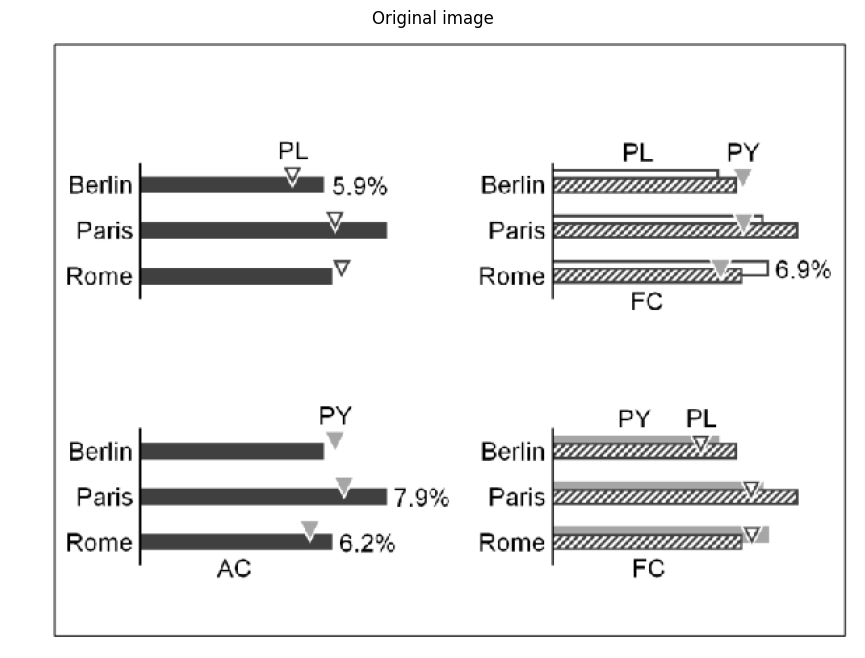

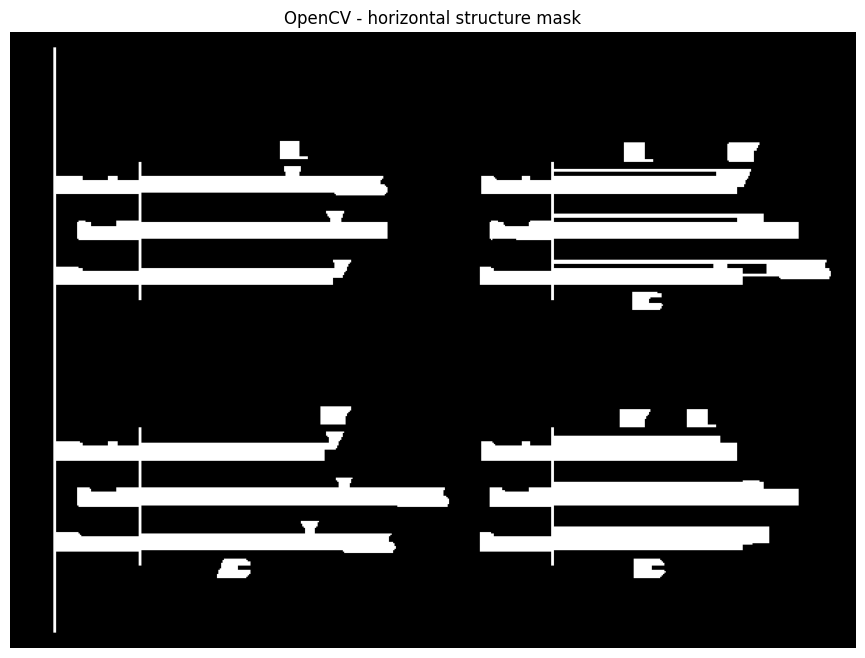

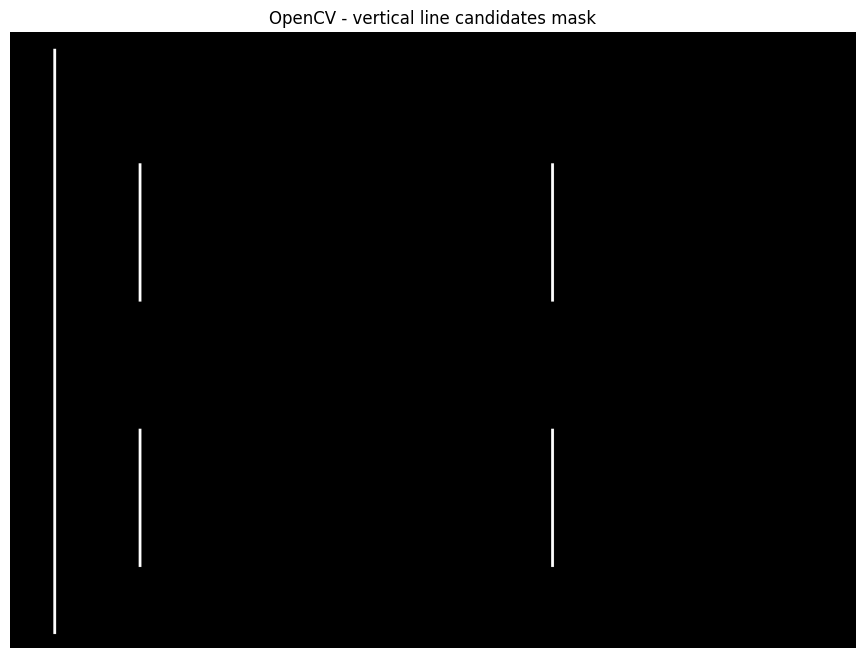

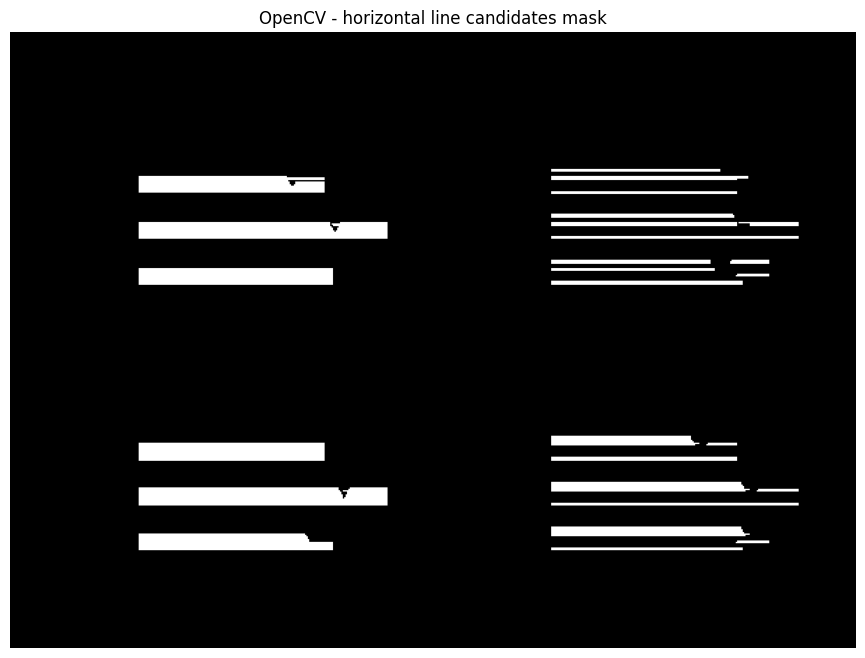

OpenCV axes found: 7


,rank,source,agreement,axis_type,x1,y1,x2,y2,supporting_bars,confidence,score,opencv_score
0,1,opencv,None,left_axis,388,278,388,392,4,None,618.8,None
1,2,opencv,None,left_axis,388,88,388,199,4,None,615.8,None
2,3,opencv,None,left_axis,93,284,93,391,4,None,611.8,None
3,4,opencv,None,bottom_x_axis,368,338,572,338,2,None,488.2,None
4,5,opencv,None,left_axis,93,94,93,189,3,None,479.8,None
5,6,opencv,None,bottom_x_axis,429,104,538,104,2,None,384.2,None
6,7,opencv,None,bottom_x_axis,430,115,529,115,2,None,372.2,None


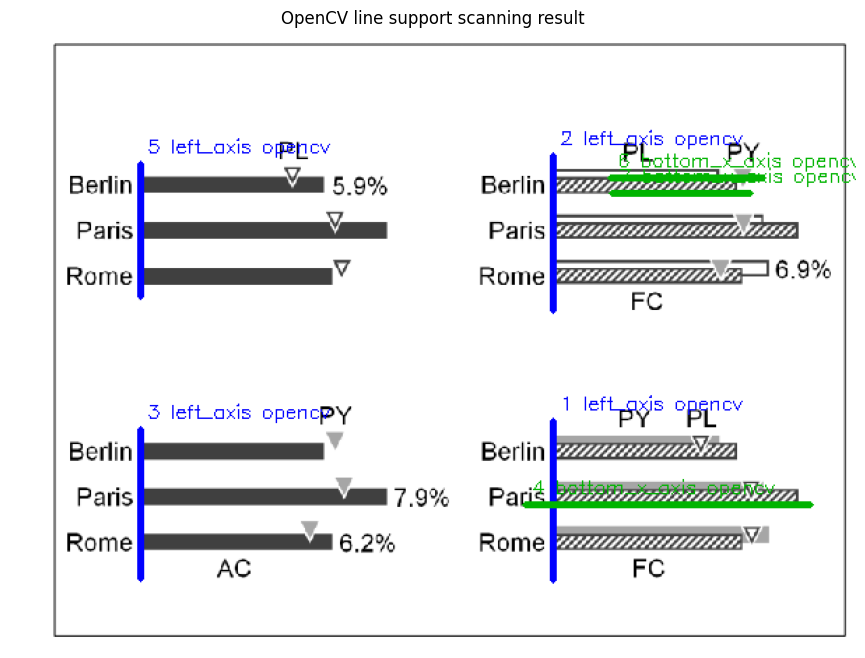

Saved OpenCV result to: ..\output\7_opencv_axes.png


In [11]:
image = load_image(IMAGE_PATH)
show_image("Original image", image)

opencv_result = run_opencv_axis_detection(image)

show_image("OpenCV - horizontal structure mask", opencv_result["horizontal_structure_mask"])
show_image("OpenCV - vertical line candidates mask", opencv_result["vertical_lines_mask"])
show_image("OpenCV - horizontal line candidates mask", opencv_result["horizontal_lines_mask"])

print("OpenCV axes found:", len(opencv_result["axes"]))
display(axes_to_dataframe(opencv_result["axes"]))

opencv_output = draw_axes(image, opencv_result["axes"], title="OpenCV line support scanning result")

opencv_output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_opencv_axes.png"
cv2.imwrite(str(opencv_output_path), opencv_output)
print("Saved OpenCV result to:", opencv_output_path)

## 4. Run YOLO if trained model exists

In [12]:
yolo_axes = run_yolo_axis_detection(IMAGE_PATH, YOLO_MODEL_PATH)

print("YOLO axes found:", len(yolo_axes))
display(axes_to_dataframe(yolo_axes))

if len(yolo_axes) > 0:
    yolo_output = draw_axes(image, yolo_axes, title="YOLO axis detection result")
    yolo_output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_yolo_axes.png"
    cv2.imwrite(str(yolo_output_path), yolo_output)
    print("Saved YOLO result to:", yolo_output_path)

No trained YOLO model found at: ..\runs\detect\train\weights\best.pt
Skipping YOLO detection and using OpenCV only.
YOLO axes found: 0


""


## 5. Combine YOLO + OpenCV

Hybrid axes found: 4


,rank,source,agreement,axis_type,x1,y1,x2,y2,supporting_bars,confidence,score,opencv_score
0,1,opencv,opencv_only,left_axis,388,278,388,392,4,None,618.8,None
1,2,opencv,opencv_only,left_axis,93,284,93,391,4,None,611.8,None
2,3,opencv,opencv_only,bottom_x_axis,368,338,572,338,2,None,488.2,None
3,4,opencv,opencv_only,bottom_x_axis,429,104,538,104,2,None,384.2,None


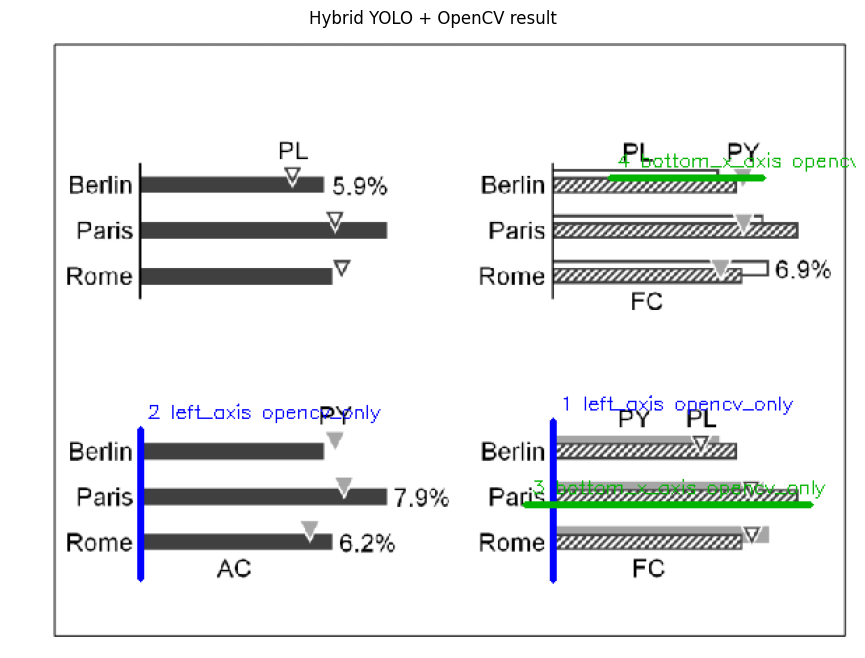

Saved hybrid result to: ..\output\7_hybrid_axes.png


In [13]:
hybrid_axes = combine_yolo_and_opencv_axes(yolo_axes, opencv_result["axes"])

print("Hybrid axes found:", len(hybrid_axes))
display(axes_to_dataframe(hybrid_axes))

hybrid_output = draw_axes(image, hybrid_axes, title="Hybrid YOLO + OpenCV result")

hybrid_output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_hybrid_axes.png"
cv2.imwrite(str(hybrid_output_path), hybrid_output)

print("Saved hybrid result to:", hybrid_output_path)

# Part D - Batch test

Deze cel runt OpenCV + YOLO + Hybrid op alle afbeeldingen in je dataset.

Als je YOLO nog niet hebt getraind, werkt de batch alsnog met OpenCV-only.


In [ ]:
DATASET_DIR = Path("../Dataset")
BATCH_OUTPUT_DIR = OUTPUT_DIR / "hybrid_batch_results"
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_extensions = [".png", ".jpg", ".jpeg", ".webp"]
image_paths = []

for ext in image_extensions:
    image_paths.extend(DATASET_DIR.rglob(f"*{ext}"))

print("Found images:", len(image_paths))

summary_rows = []

for path in image_paths:
    try:
        img = load_image(path)

        opencv_res = run_opencv_axis_detection(img)
        yolo_res = run_yolo_axis_detection(path, YOLO_MODEL_PATH)
        hybrid_res = combine_yolo_and_opencv_axes(yolo_res, opencv_res["axes"])

        out = draw_axes(img, hybrid_res, title=f"Hybrid result: {path.name}", max_axes=MAX_AXES_TO_DRAW)

        relative = path.relative_to(DATASET_DIR)
        save_path = BATCH_OUTPUT_DIR / relative
        save_path.parent.mkdir(parents=True, exist_ok=True)

        cv2.imwrite(str(save_path), out)

        summary_rows.append({
            "image": str(relative),
            "opencv_axes": len(opencv_res["axes"]),
            "yolo_axes": len(yolo_res),
            "hybrid_axes": len(hybrid_res),
            "output": str(save_path)
        })

        print("Saved:", save_path)

    except Exception as e:
        print("Error with", path, ":", e)

summary_df = pd.DataFrame(summary_rows)
summary_df

# Part E - How to label for YOLO

Voor YOLO moet je afbeeldingen labelen.

Gebruik bijvoorbeeld:
- Roboflow
- CVAT
- LabelImg
- makesense.ai

## Classes

```text
0: left_axis
1: bottom_x_axis
```

## Labelregels

### Horizontal bar chart

Label de verticale as links als `left_axis`.

```text
Berlin |████
Paris  |██████
Rome   |███
       ↑
       left_axis
```

### Vertical bar chart

Label de horizontale as onderaan als `bottom_x_axis`.

```text
  █   █   █
  █   █   █
────────────
     ↑
     bottom_x_axis
```

Als er meerdere kleine charts in één afbeelding staan, label je alle assen apart.


# Report explanation

You can use this text:

> This project uses a hybrid approach to detect chart axes. First, an OpenCV baseline is used with line support scanning. This method detects possible axis lines and checks whether nearby bar pixels support the line. For horizontal bar charts, a vertical line is accepted as a left axis when multiple horizontal bar segments start to its right. For vertical bar charts, a horizontal line is accepted as a bottom x-axis when multiple vertical bar segments end above it. Because the dataset contains multiple charts, dividers, labels and different orientations, a YOLO object detection model is added as a learning-based solution. YOLO is trained to detect two classes: `left_axis` and `bottom_x_axis`. The hybrid method combines YOLO predictions with OpenCV support. When YOLO and OpenCV detect a similar axis, the detection is considered stronger. This combines the flexibility of object detection with the explainability of rule-based computer vision.

Limitations:

> The OpenCV part is rule-based and can still fail when bars or axes are unclear. YOLO requires labelled training data and enough examples to generalize to different chart styles. The hybrid approach is expected to be more robust than OpenCV alone, but it still needs visual evaluation on compliant and non-compliant chart images.
